In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# Deep Neural Networks 
## Template 02
- multi-class - Fashion MNIST dataset (all 60000 images)

<img src='../../prasami_images/prasami_color_tutorials_small.png' width='400' alt="By Pramod Sharma : pramod.sharma@prasami.com"/>

In [31]:
###-----------------
### Import Libraries
###-----------------

###-----------------
### Import libraries
###-----------------
from pathlib import Path  # Import Path for file system path operations and management
import numpy as np  # Import NumPy for numerical computations and array operations
import pandas as pd  # Import Pandas for data manipulation and analysis with DataFrames
import matplotlib.pyplot as plt  # Import Matplotlib for creating static, interactive visualizations
import seaborn as sns  # Import Seaborn for statistical data visualization built on Matplotlib
import tensorflow as tf
from sklearn.model_selection import train_test_split  # Import function to split dataset into training and testing subsets
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, f1_score  # Import function to calculate various metric

# from utils.helper import fn_plot_confusion_matrix

In [3]:
# Some basic parameters
#inpDir = '../../input' 
inpDir = Path('..') / '..' / 'input'
# outDir = '../output'
outDir = Path('..') / 'output'
subDir = 'fashion_MNIST' # location of the images
modelDir = Path('..') / 'models'
altName = 'tf_fashion_all'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
rng = np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible  results
tf.random.set_seed(seed=RANDOM_STATE)

EPOCHS = 50 # number of cycles to run
ALPHA = 0.001 # learning rate
BATCH_SIZE=32

# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,9),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

plt.rcParams.update(params) # update rcParams
CMAP = plt.cm.coolwarm
plt.style.use('seaborn-v0_8-darkgrid') # plt.style.use('ggplot')

In [4]:
physical_devices=tf.config.list_logical_devices('GPU')
if len(physical_devices)>0:
    tf.config.experimental.set_memory_growth(physical_devices[0],True)
print(tf.__version__,physical_devices)

2.21.0 []


# Helper Function

In [5]:
def fn_plot_labels(train_df,test_df):
    plt.figure(figsize=(15,5))
    plt.subplot(1,2,1)
    ax=train_df['label'].value_counts().plot(kind='bar',
                                          title='Train',
                                          color='DarkBlue',
                                          alpha=0.7)
    plt.subplot(1,2,2)
    ax=test_df['label'].value_counts().plot(kind='bar',
                                          title='Test',
                                          color='Orange',
                                          alpha=0.7)

## Load Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from TensorFlow. Import and [load the Fashion MNIST data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) directly from TensorFlow:

In [6]:
train_filename ='fashion-mnist_train.csv'
test_filename = 'fashion-mnist_test.csv'

train_df = pd.read_csv(train_filename, header = 0)
test_df = pd.read_csv(test_filename, header = 0)

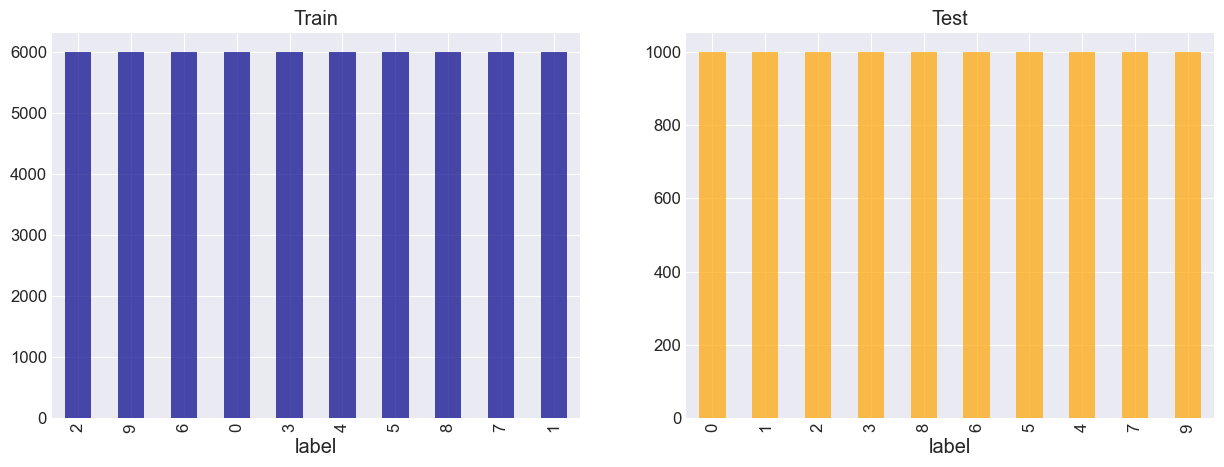

In [7]:
fn_plot_labels(train_df,test_df)

In [8]:
def split_feature_label(row):
    feature = tf.reshape(row[1:], [28,28,1])
    label = row[0]
    return feature, label

In [9]:
tmp_ds=tf.data.Dataset.from_tensor_slices(train_df)
train_ds=tmp_ds.map(split_feature_label)

train_ds=train_ds.cache()
train_ds=train_ds.batch(BATCH_SIZE)
train_ds=train_ds.prefetch(tf.data.AUTOTUNE)

In [10]:
#class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
#               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_names = {0: 'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',
               5:'Sandal', 6: 'Shirt',7: 'Sneaker', 8:'Bag', 9: 'Ankle boot'}

In [11]:
tmp_ds=tf.data.Dataset.from_tensor_slices(test_df)
test_ds=tmp_ds.map(split_feature_label)

test_ds=test_ds.cache()
test_ds=test_ds.batch(BATCH_SIZE)
test_ds=test_ds.prefetch(tf.data.AUTOTUNE)

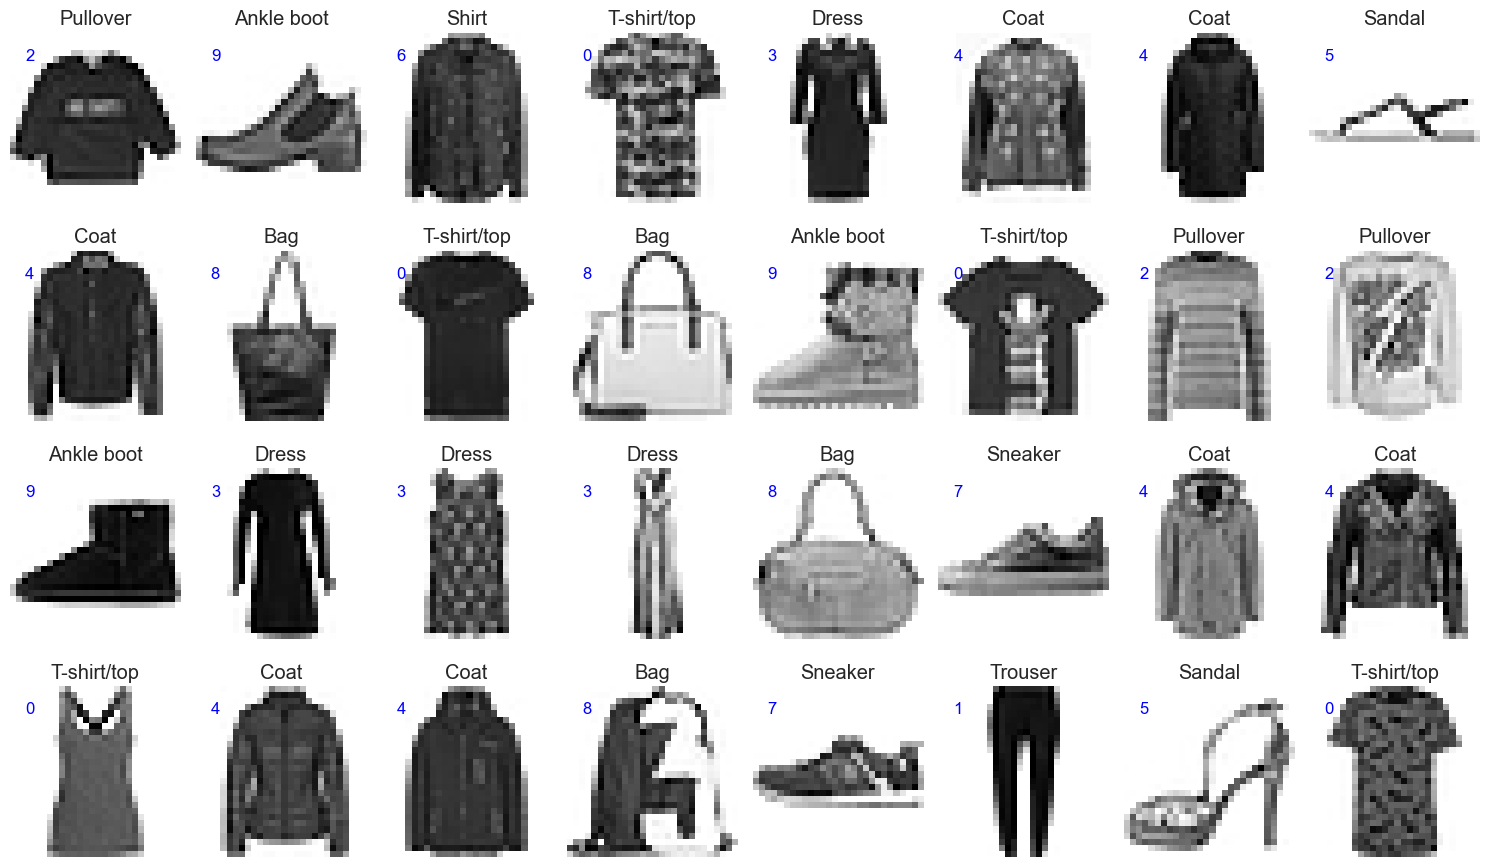

In [12]:
for images,labels in train_ds.take(1):
    for i in range(BATCH_SIZE):
        plt.subplot(BATCH_SIZE//8,8,i+1)
        plt.grid(False)
        plt.imshow(images[i].numpy().astype('uint8'),cmap=plt.cm.binary)
        plt.title(class_names[labels[i].numpy()])
        plt.text(2,4,labels[i].numpy(),c='b',fontsize=12)
        plt.axis('off')
    plt.tight_layout()

In [13]:
normalization_layer=tf.keras.layers.Rescaling(1/255.)
images,labels=next(iter(train_ds))
img=images[0].numpy()
print(f'Original:Min:{img.min()},Max:{img.max()},Std:{img.std()}')
norm_ds=train_ds.map(lambda x,y:(normalization_layer(x),y))
images,labels=next(iter(norm_ds))
img=images[0].numpy()
print(f'Normalized: Min:{img.min()}, Max:{img.max()}, Std:{img.std()}')

Original:Min:0,Max:255,Std:103.16875931594878
Normalized: Min:0.0, Max:1.0, Std:0.4045833945274353


<Axes: >

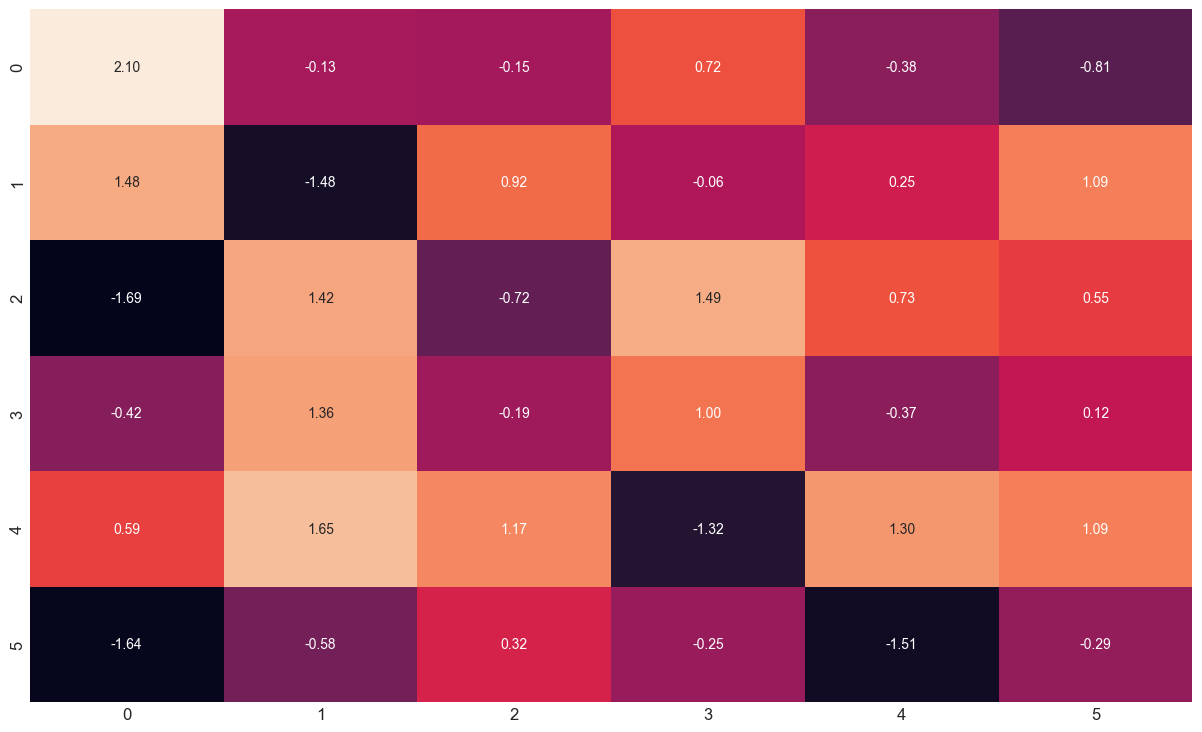

In [14]:
input_shape=(1,6,6,1)
X=tf.random.normal(input_shape)
sns.heatmap(X.numpy()[0,:,:,0],annot=True,fmt='.2f',cbar=False)

<Axes: >

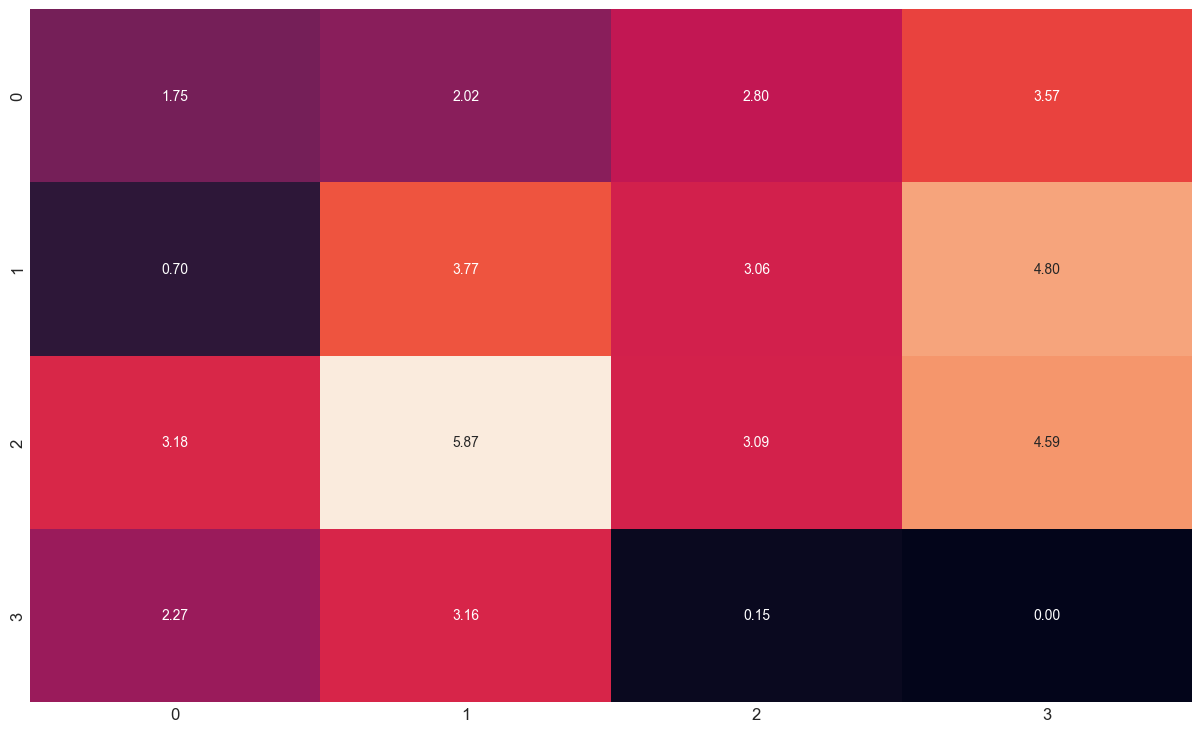

In [15]:
y=tf.keras.layers.Conv2D(1,3,kernel_initializer=tf.constant_initializer(1.0),
                        use_bias=False,
                        activation='relu')(X)
sns.heatmap(y.numpy()[0,:,:,0],annot=True,fmt='.2f',cbar=False)

<Axes: >

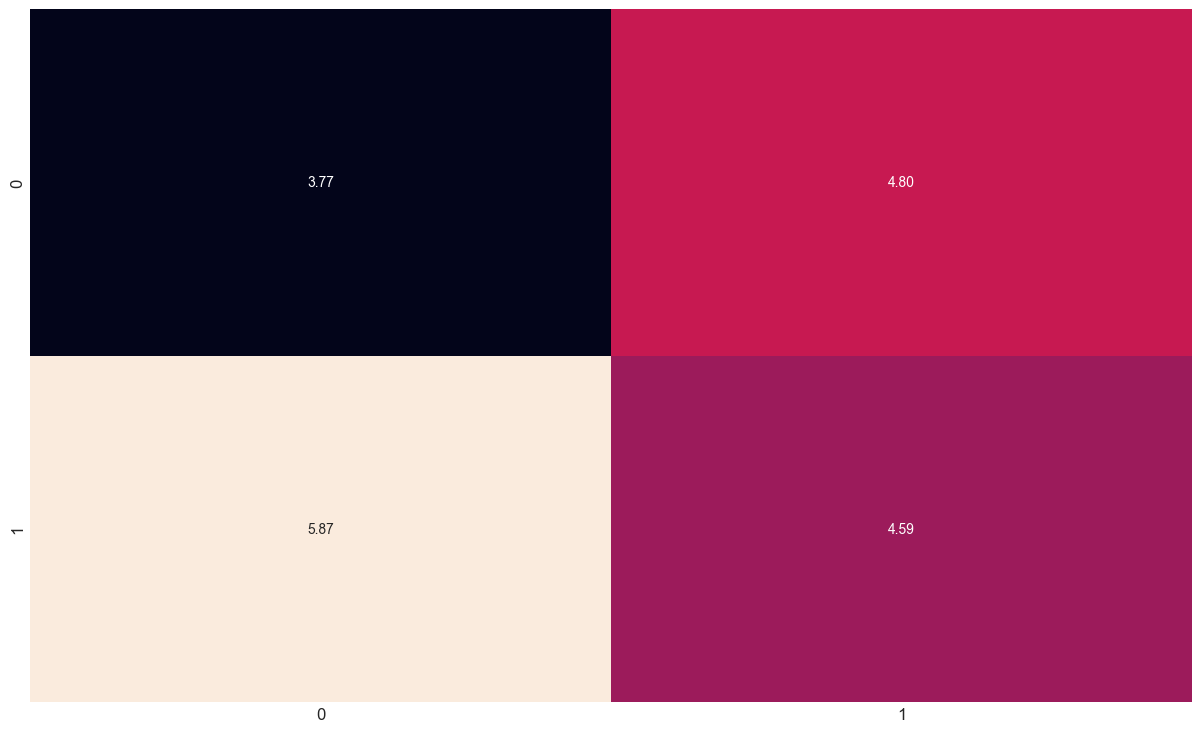

In [16]:
max_pool_2d=tf.keras.layers.MaxPool2D(pool_size=(2,2),
                                     strides=None,
                                     padding='valid')
z=max_pool_2d(y)
sns.heatmap(z.numpy()[0,:,:,0],annot=True,fmt='.2f',cbar=False)

In [17]:
krnl_init=tf.keras.initializers.GlorotUniform(seed=RANDOM_STATE)
input_shape=(28,28,1)
dor1=0.1
dor2=0.2
dor3=0.3
dor4=0.4

model=tf.keras.Sequential()
model.add(tf.keras.layers.Input(shape=input_shape))
model.add(tf.keras.layers.Rescaling(1./255.))
#Set1
model.add(tf.keras.layers.Conv2D(32,(3,3),
                                kernel_initializer=krnl_init,
                                padding='same'))
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool2D())
model.add(tf.keras.layers.Dropout(rate=dor1))
#Set2
model.add(tf.keras.layers.Conv2D(64,(3,3),
                                kernel_initializer=krnl_init))
# model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool2D())
model.add(tf.keras.layers.Dropout(rate=dor2))

#Set3
model.add(tf.keras.layers.Conv2D(128,(3,3),
                                kernel_initializer=krnl_init,
                                activation='relu'))
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool2D())
model.add(tf.keras.layers.Dropout(rate=dor3))

#Head
model.add(tf.keras.layers.Flatten())

#Dense
model.add(tf.keras.layers.Dense(10,
                                kernel_initializer=krnl_init))
print(model.summary())


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)              │ (None, 28, 28, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 28, 28, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 28, 28, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 14, 14, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 12, 12, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 4, 4, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 97,802 (382.04 KB)

 Trainable params: 97,802 (382.04 KB)

 Non-trainable params: 0 (0.00 B)

None


In [18]:
optimizer=tf.keras.optimizers.Adam(learning_rate=ALPHA)
loss_fn=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)

model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy'])

In [19]:
hist=model.fit(train_ds,epochs=EPOCHS,batch_size=BATCH_SIZE,validation_data=test_ds)

Epoch 1/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 31s 15ms/step - accuracy: 0.8004 - loss: 0.5474 - val_accuracy: 0.8719 - val_loss: 0.3551
Epoch 2/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8672 - loss: 0.3619 - val_accuracy: 0.8960 - val_loss: 0.2883
Epoch 3/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.8851 - loss: 0.3162 - val_accuracy: 0.8995 - val_loss: 0.2727
Epoch 4/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 29s 15ms/step - accuracy: 0.8938 - loss: 0.2907 - val_accuracy: 0.9087 - val_loss: 0.2550
Epoch 5/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9001 - loss: 0.2707 - val_accuracy: 0.9073 - val_loss: 0.2563
Epoch 6/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9049 - loss: 0.2576 - val_accuracy: 0.9185 - val_loss: 0.2263
Epoch 7/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9094 - loss: 0.2466 - val_accuracy: 0.9104 - val_loss: 0.2482
Epoch 8/50
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9109 -

In [20]:
loss_df=pd.DataFrame(hist.history)
loss_df.head()

,accuracy,loss,val_accuracy,val_loss
0,0.800350,0.547434,0.8719,0.355132
1,0.867233,0.361914,0.8960,0.288268
2,0.885133,0.316169,0.8995,0.272733
3,0.893783,0.290686,0.9087,0.254966
4,0.900083,0.270696,0.9073,0.256282


In [21]:
###-----------------------------------------------------------
### Function to plot Loss Curve using Tensorflow history object
###------------------------------------------------------------

def fn_plot_tf_hist(hist_df):
    
    '''
    Args:
        hist_df: a DataFrame with column names accuracy,loss	val_accuracy	val_loss
    '''
        
    fig, axes = plt.subplots(1,2 , figsize = (15,6))

    # properties  matplotlib.patch.Patch 
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    facecolor = 'cyan'
    fontsize=12
    CMAP = plt.cm.coolwarm
    
    # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]

    # Where was min loss
    best = hist_df[hist_df[y4] == hist_df[y4].min()]
    
    ax = axes[0]

    hist_df.plot(y = [y2,y4], ax = ax, colormap=CMAP)


    # little beautification
    txtFmt = "Loss: \n  train: {:6.4f}\n   test: {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y2],
                           hist_df.iloc[-1][y4]) #text to plot
    
    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)
    
    # calculate offset for arrow
    y_min = min(hist_df[y2].min(), hist_df[y4].min())
    y_max = max(hist_df[y2].max(), hist_df[y4].max())
    offset = (y_max-y_min)/10.0
    
    best_idx = best.index.to_numpy()[0]  # Extract first (and only) element as scalar
    best_value = best[y4].to_numpy()[0]   # Extract scalar value
    
    # Mark arrow at lowest
    ax.annotate(f'Min: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value + offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y2.capitalize())
    ax.set_title('Loss Curve')
    ax.grid(True)
    ax.legend(loc = 'upper left') # model legend to upper left
    
    ax = axes[1]

    hist_df.plot( y = [y1, y3], ax = ax, colormap=CMAP)
    
    # little beautification
    txtFmt = "Accuracy: \n  train: {:6.4f}\n  test:  {:6.4f}"
    txtstr = txtFmt.format(hist_df.iloc[-1][y1],
                           hist_df.iloc[-1][y3]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.2, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arroe
    y_min = min(hist_df[y1].min(), hist_df[y3].min())
    y_max = max(hist_df[y1].max(), hist_df[y3].max())
    offset = (y_max-y_min)/10.0

    best_value = best[y3].to_numpy()[0]   # Extract scalar value
    # Mark arrow at lowest
    ax.annotate(f'Best: {best_value:6.4f}', # text to print
                xy=(best_idx, best_value), # Arrow start
                xytext=(best_idx, best_value-offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    
    # Draw vertical line at best value
    ax.axvline(x = best_idx, color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y1.capitalize())
    ax.set_title('Accuracy Curve')
    ax.grid(True)
    ax.legend(loc = 'lower left')
    
    plt.tight_layout()

In [34]:
def fn_plot_confusion_matrix(y_true, y_pred, labels):
    '''
    Args:
        y_true: Ground Truth 
        y_pred : Predictions
        labels : dictonary
    
    '''
    
    cm  = confusion_matrix(y_true, y_pred)
    
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=labels.values())
    
    fig, ax = plt.subplots(figsize = (4,4))
    
    disp.plot(ax = ax, cmap = 'Blues', xticks_rotation = 'vertical', colorbar=False)
    # Disable the grid
    ax.grid(False)
    ax.set_title(f"F1_Score: {f1_score(y_true,y_pred, average='weighted'):0.4f}")
    plt.show()

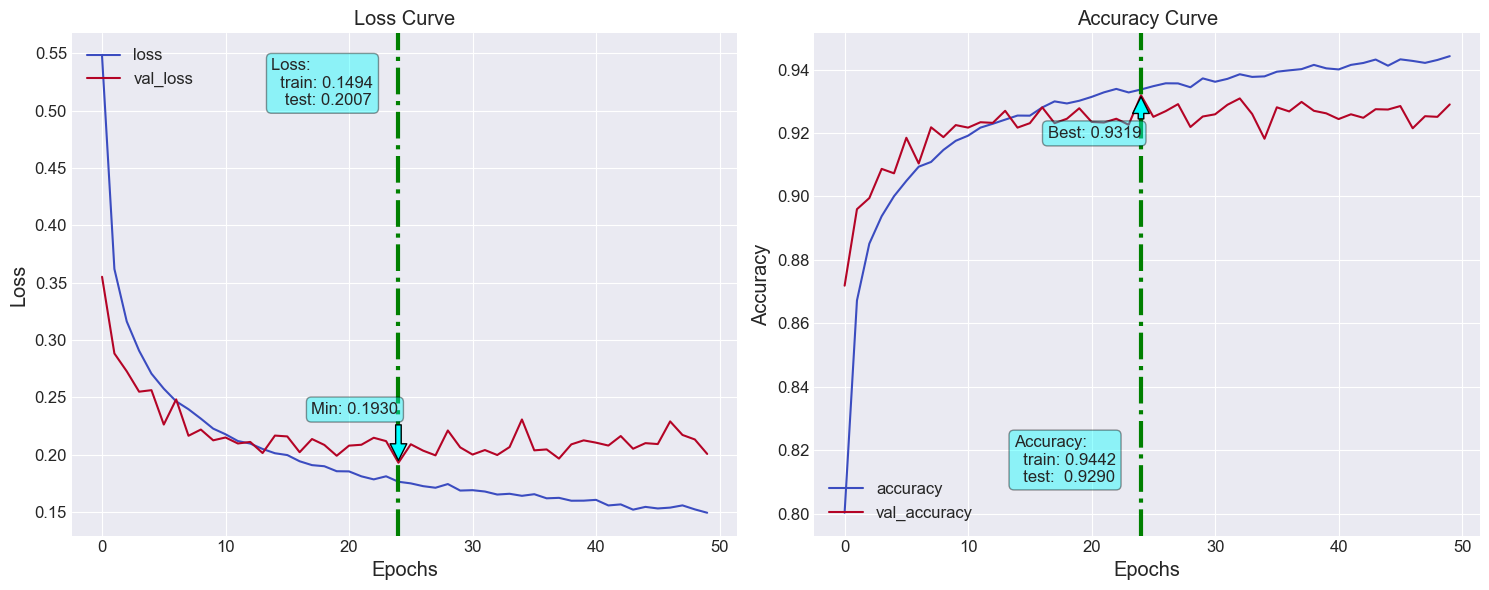

In [35]:
fn_plot_tf_hist(loss_df)

In [36]:
loss_df[loss_df['val_loss'] == loss_df['val_loss'].min()]

,accuracy,loss,val_accuracy,val_loss
24,0.933717,0.176451,0.9319,0.193037


In [37]:
#Predictions on train dataset
y_true, y_pred=[],[]
for features, labels in train_ds:
    pred=model(features, training=False)
    pred = pred.numpy().argmax(axis=1)
    y_pred.append(pred)
    y_true.append(labels.numpy())

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)
accuracy_score(y_true, y_pred)


0.9758666666666667

In [40]:
print(classification_report(y_true, y_pred, target_names=list(class_names.values())))

              precision    recall  f1-score   support

 T-shirt/top       0.95      0.97      0.96      6000
     Trouser       1.00      1.00      1.00      6000
    Pullover       0.96      0.95      0.96      6000
       Dress       0.97      0.99      0.98      6000
        Coat       0.95      0.96      0.96      6000
      Sandal       1.00      1.00      1.00      6000
       Shirt       0.94      0.91      0.92      6000
     Sneaker       0.99      0.99      0.99      6000
         Bag       1.00      1.00      1.00      6000
  Ankle boot       0.99      0.99      0.99      6000

    accuracy                           0.98     60000
   macro avg       0.98      0.98      0.98     60000
weighted avg       0.98      0.98      0.98     60000



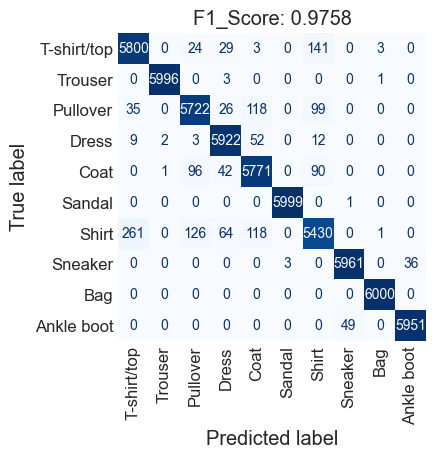

In [41]:
fn_plot_confusion_matrix(y_true,y_pred,class_names)

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [39]:
y_pred = probability_model(X_test).numpy()

print('Accuracy score on Test Data :{:.5f}'.format(accuracy_score(y_test, 
                                                                  np.argmax(y_pred, axis = 1))))

NameError: name 'probability_model' is not defined

## Explore the data

Let's explore the format of the dataset before training the model. The following shows there are 60,000 images in the training set, with each image represented as 28 x 28 pixels:

In [ ]:
train_df.head()

In [ ]:
train_df.shape, test_df.shape

Each label is an integer between 0 and 9:

In [ ]:
train_df['label'].unique()

## Whats in the data?

In [ ]:
# Sample data plot

plot_df = train_df.sample(n = 100) # Take 100 sample from the training set

fig = plt.figure(figsize=(15, 12))  # figure size in inches

fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05) # adjust subplots

i = 0

for _ , row in plot_df.iterrows(): # iterate through all rows of the dataframe
    
    i = i + 1
    
    image = row.values[1:].reshape(28,28) # reshape row to a 28x28 matrix
    
    ax = fig.add_subplot(10, 10, (i), xticks=[], yticks=[]) # add a subplot to the figure
    
    ax.imshow(image, cmap=plt.cm.binary, interpolation='nearest') # show image on the axis
    
    ax.text(2, 4, str(row.iloc[0]), color='b', fontsize=16)   # add number (class) of the image
    
    ax.text(2, 25, class_names[row.iloc[0]], color='r', fontsize=16)   # add name of the image
    
plt.show()

## Preprocess the data

The data must be preprocessed before training the network. If you inspect the first image in the training set, you will see that the pixel values fall in the range of 0 to 255:

Scale these values to a range of 0 to 1 before feeding them to the neural network model. To do so, divide the values by 255. It's important that the *training set* and the *testing set* be preprocessed in the same way:

In [ ]:
X_train = train_df.drop('label', axis = 1).to_numpy()
y_train = train_df['label'].to_numpy()

X_test = test_df.drop('label', axis = 1).to_numpy()
y_test = test_df['label'].to_numpy()

X_train.shape, X_test.shape, y_train.shape, y_test.shape

In [ ]:
X_train = X_train / 255.0

X_test = X_test / 255.0